# Polynomial Demonstration 

In this demo, we illustrate the command response design with a simple polynomial example.  The accelerator computes a polynomial function of `x[k]`:

```python
y[k] = a[0] + a[1]*x[k] + ... + a[d-1]*x[k]**d
```

All the examples can be found in `hwdesign/demos/stream` with the main notebook in `poly_demo.ipynb`.

## Protocol

The IP we will build will follow the folliwng command-response FIFO protocol:

- The PS sends a `PolyCmdHdr` with the coefficients, `coeffs`, number of samples, `nsamp`, and a transaction ID, `tx_id`.
- The IP repsonds with a `PolyRespHdr` message with the transcation ID, `tx_id`.  This ensures that the IP is in sync and has received the data.
- The PS then starts streaming the input data `x` as a vector of floating point values.
- As the data streams in, the IP computes the output data vector `y`
- When complete the IP sends a `PolyRespFtr` message with an indication of the number of samples and any error code.

## Message Definitions

To better organize the code, is useful to represent both the command and response via **data structures**, specifically C++ classes.   We will write the messages in python using tools from the PySilicon package.  Although this package is the hwdesign repo, it is a mirror image of the package [PySilicon](https://sdrangan.github.io/pysilicon/docs/) that I developing separately.  Eventually, we will just move to that repo.  

The PySilicon package defines messages with **data schemas**.  A complete discussion can be found in [Pysilicon documentation on data schemas](https://sdrangan.github.io/pysilicon/docs/guide/schema/).  We first import the relevant modules.

In [19]:
import sys
from enum import IntEnum
from pathlib import Path

import numpy as np

from pysilicon.build.build import CodeGenConfig
from pysilicon.build.streamutils import copy_streamutils
from pysilicon.hw.arrayutils import gen_array_utils, read_array, get_nwords
from pysilicon.hw.dataschema import DataArray, DataList, EnumField, FloatField, IntField
from pysilicon.toolchain import toolchain, run_vitis_hls_result
from pysilicon.utils.vcd import VcdParser
from pysilicon.utils.timing import TimingDiagram, SigTimingInfo

In the PySilicon package, messages are defined as DataSchemas, which are simply python classes that can be used to describe the fields for each message.  The messages are below.

In [20]:

# Parameters
include_dir = "include"  # Directory for generated header files
word_bw_supported = [32, 64]  # Supported word bitwidths for the generated code
max_nsamp = 128  # Maximum number of samples for the input and output data arrays


# Element types
Float32 = FloatField.specialize(bitwidth=32, include_dir=include_dir)
TransId = IntField.specialize(bitwidth=16, signed=False, include_dir=include_dir)
Nsamp = IntField.specialize(bitwidth=16, signed=False, include_dir=include_dir)

# Error codes for polynomial evaluation results
class PolyError(IntEnum):
    NO_ERROR = 0
    TLAST_EARLY_CMD_HDR = 1  # TLAST was asserted before the full command header was received
    NO_TLAST_CMD_HDR = 2  # The full command header was received but TLAST was never asserted
    TLAST_EARLY_SAMP_IN = 3  # TLAST was asserted before all input samples were received
    NO_TLAST_SAMP_IN = 4  # All input samples were received but TLAST was never asserted
    WRONG_NSAMP = 5  # The number of samples received does not match the expected number
PolyErrorField = EnumField.specialize(enum_type=PolyError, include_dir=include_dir)


# Coefficient array for polynomial evaluation (4 coefficients for a cubic polynomial)
class CoeffArray(DataArray):
    ncoeffs = 4
    element_type = Float32
    static = True
    max_shape = (ncoeffs,)
    include_dir = include_dir


# Data structures for the command and response headers and footers
class PolyCmdHdr(DataList):
    elements = {
        "tx_id": {
            "schema": TransId,
            "description": "Transaction ID",
        },
        "coeffs": {
            "schema": CoeffArray,
            "description": "Polynomial coefficients",
        },
        "nsamp": {
            "schema": Nsamp,
            "description": "Number of samples",
        },
    }
    include_dir = include_dir


class PolyRespHdr(DataList):
    elements = {
        "tx_id": {
            "schema": TransId,
            "description": "Echo of the transaction ID sent in the command",
        },
    }
    include_dir = include_dir


class PolyRespFtr(DataList):
    elements = {
        "nsamp_read": {
            "schema": Nsamp,
            "description": "Number of samples returned in the response",
        },
        "error": {
            "schema": PolyErrorField,
            "description": "Error code indicating success or type of failure",
        },
    }
    include_dir = include_dir


# List of all schema classes to be included in the generated code
schema_classes = [
    PolyErrorField,
    CoeffArray,
    PolyCmdHdr,
    PolyRespHdr,
    PolyRespFtr,
]

## Generating the Include Files

Once the Data schemas are defined, we can auto-generate the C++ header files.  Header files are generated for each data schema.  The header files provide:

- A C++ data structure for the data.
- Serialization and deserialization methods to store and transfer that data over various interfaces including AXI4-Stream

Auto-generating the include files avoids having to manually align the Python and C++ versions of data as well as manually packing and unpacking data for specific bitwidths.  All of this is done automatically.  Details are given in [PySilicon auto-generation documentation](https://sdrangan.github.io/pysilicon/docs/guide/schema/codegen.html).  Inlcude files can be generated from the  `gen_include` method.  For example, running `PolyCmdHdr.gen_include(....)` will generate two header files:

- `poly_cmd_hdr.h`:  The main header for use in Vitis synthesizable code. This file defines the C++ data structure as well as templated serialization and deserialization routines.
- `poly_cmd_hdr_tb.h`:  A companion header for non-synthesizable Vitis code such as testbenches. This file adds routines for reading/writing files and JSON dumps.

The code below loops through the data schemas and generates all the relevant files.


In [21]:
# Make the include directory
include_dir = Path.cwd() / include_dir
include_dir.mkdir(exist_ok=True)

# Remove any existing header files in the include directory
for header_file in include_dir.glob("*.h"):
    header_file.unlink()

# Create a code generation configuration and generate the header files for all schema classes
cfg = CodeGenConfig(root_dir=Path.cwd(), util_dir=include_dir)

# Generate header files for all schema classes
for schema_class in schema_classes:
    out_path = schema_class.gen_include(cfg=cfg, word_bw_supported=word_bw_supported)
    print(f"generated {out_path}")


generated c:\Users\sdran\Documents\repos\hwdesign\demos\stream\include\poly_error.h
generated c:\Users\sdran\Documents\repos\hwdesign\demos\stream\include\coeff_array.h
generated c:\Users\sdran\Documents\repos\hwdesign\demos\stream\include\poly_cmd_hdr.h
generated c:\Users\sdran\Documents\repos\hwdesign\demos\stream\include\poly_resp_hdr.h
generated c:\Users\sdran\Documents\repos\hwdesign\demos\stream\include\poly_resp_ftr.h


We also have to generate various general streaming utilities as well as utilies for floating point values.  This generation is done with the following code

In [22]:
# Generate the float32 include file with array utilities for the supported word bitwidths
out_path = gen_array_utils(Float32, word_bw_supported=word_bw_supported, cfg=cfg)
print(f"generated {out_path}")

# Copy the streamutils header file to the root directory
copy_streamutils(cfg=cfg)

generated c:\Users\sdran\Documents\repos\hwdesign\demos\stream\include\float32_array_utils.h


('C:\\Users\\sdran\\Documents\\repos\\hwdesign\\demos\\stream\\include\\streamutils_hls.h',
 'C:\\Users\\sdran\\Documents\\repos\\hwdesign\\demos\\stream\\include\\streamutils_tb.h')

## Run C-Simulation the Design

We now run the C-Simulation of the kernel and testbench.   You can run this from a terminal:

```bash
vitis-run --mode hls --tcl run_hls_poly.tcl
```

Alternatively, you can just run this python command which is basically a wrapper on this command.

This will take about a minute since it runs the C-simulation, C-synthesis, and RTL

In [5]:
#run_vitis_hls_result("run_hls_poly.tcl", output_path="vitis_run.txt")

## View the Timing

The Vitis C simulation does not generally produce a timing waveform that can be easily read into python.  So, we re-run the simulation with the following command to capture a VCD file.  

```bash
xsim_vcd --top poly --comp poly_proj --out dump_poly.vcd
```

You can run this command at the command window.   

In [23]:
from vcdvcd import VCDVCD
import matplotlib.pyplot as plt

# Check if VCD file exists
vcd_file = 'dump_poly.vcd'
import os
fn = os.path.join(os.getcwd(), 'vcd', vcd_file)
if not os.path.exists(fn):
    raise FileNotFoundError(f"VCD file not found: {fn}")

# Parse the VCD file
vcd = VCDVCD(fn, signals=None, store_tvs=True)

In [24]:
nsig = len(vcd.signals)
print(f"Number of signals in VCD: {nsig}")

# Find the signals with TDATA and TREADY in their names
tdatas = [s for s in vcd.signals if 'TDATA' in s]
print(tdatas)


Number of signals in VCD: 1131
['apatb_poly_top.in_stream_TDATA[31:0]', 'apatb_poly_top.out_stream_TDATA[31:0]', 'apatb_poly_top.AESL_inst_poly.in_stream_TDATA[31:0]', 'apatb_poly_top.AESL_inst_poly.out_stream_TDATA[31:0]', 'apatb_poly_top.AESL_inst_poly.in_stream_TDATA_blk_n', 'apatb_poly_top.AESL_inst_poly.out_stream_TDATA_blk_n', 'apatb_poly_top.AESL_inst_poly.grp_poly_Pipeline_VITIS_LOOP_58_1_fu_258_out_stream_TDATA[31:0]', 'apatb_poly_top.AESL_inst_poly.out_stream_TDATA_reg[31:0]', 'apatb_poly_top.AESL_inst_poly.in_stream_TDATA_int_regslice[31:0]', 'apatb_poly_top.AESL_inst_poly.out_stream_TDATA_int_regslice[31:0]', 'apatb_poly_top.AESL_inst_poly.grp_poly_Pipeline_VITIS_LOOP_325_1_fu_239.in_stream_TDATA[31:0]', 'apatb_poly_top.AESL_inst_poly.grp_poly_Pipeline_VITIS_LOOP_325_1_fu_239.in_stream_TDATA_blk_n', 'apatb_poly_top.AESL_inst_poly.grp_poly_Pipeline_VITIS_LOOP_58_1_fu_258.in_stream_TDATA[31:0]', 'apatb_poly_top.AESL_inst_poly.grp_poly_Pipeline_VITIS_LOOP_58_1_fu_258.out_strea

In [25]:
from pysilicon.utils.vcd import VcdParser
from pysilicon.utils.timing import TimingDiagram

In [26]:
# Create a parsing class
vp = VcdParser(vcd)

# Get the clock signal name
clk_name = vp.add_clock_signal()

top_name = 'AESL_inst_poly'
in_stream_name = f"{top_name}.in_stream_"
out_stream_name = f"{top_name}.out_stream_"

    
# Get the  AXI-Stream command signals
in_str_sigs, in_bw = vp.add_axiss_signals(name=in_stream_name, short_name_prefix='in_stream',
                                           ignore_multiple=True)
print(in_str_sigs)

# Get the output AXI-Stream signals
out_str_sigs, out_bw = vp.add_axiss_signals(name=out_stream_name, short_name_prefix='out_stream',
                                            ignore_multiple=True)
print(out_str_sigs)


{'tdata': 'apatb_poly_top.AESL_inst_poly.in_stream_TDATA[31:0]', 'tvalid': 'apatb_poly_top.AESL_inst_poly.in_stream_TVALID', 'tready': 'apatb_poly_top.AESL_inst_poly.in_stream_TREADY', 'tlast': 'apatb_poly_top.AESL_inst_poly.in_stream_TLAST[0:0]'}
{'tdata': 'apatb_poly_top.AESL_inst_poly.out_stream_TDATA[31:0]', 'tvalid': 'apatb_poly_top.AESL_inst_poly.out_stream_TVALID', 'tready': 'apatb_poly_top.AESL_inst_poly.out_stream_TREADY', 'tlast': 'apatb_poly_top.AESL_inst_poly.out_stream_TLAST[0:0]'}


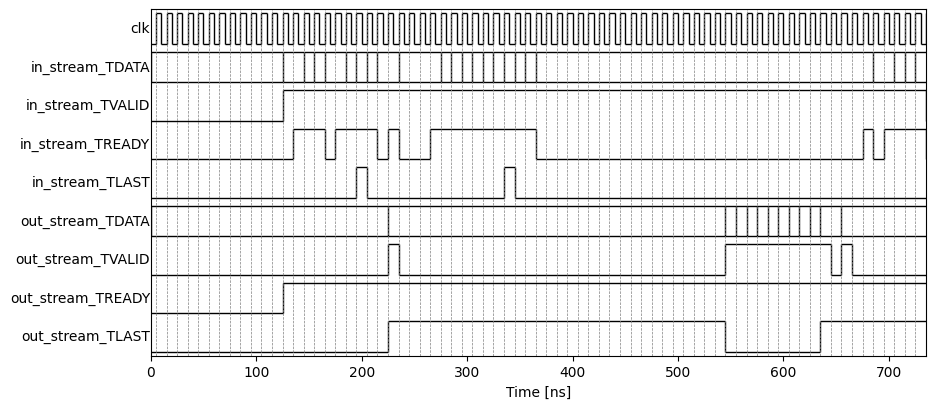

In [27]:
# Get the timing signals
sig_list = vp.get_td_signals()

# Create the timing diagram
td = TimingDiagram()
td.add_signals(sig_list)
trange = None
ax = td.plot_signals(add_clk_grid=True, trange=trange, 
                text_scale_factor=1e4, text_mode='never')
_ = ax.set_xlabel('Time [ns]')

The VCD parser has a method `extract_axis_bursts` that will extract the bursts in the stream.  We use this to print the bursts.  You will see that there are two bursts on the input, corresponding to the input command header and input data.  The output has three bursts corresponding to the response header, output data, and response footer.

In [28]:
# Extract the AXI-Stream bursts and print the burst information for the input
bursts_in, clk_period= vp.extract_axis_bursts(clk_name, in_str_sigs)
print('Input AXI-Stream bursts:')
for i, burst in enumerate(bursts_in):
    nbeats = len(burst['beat_type'])
    nbeats_transfer = sum(1 for bt in burst['beat_type'] if bt == 0)
    print(f"Burst {i}: tstart = {burst['tstart']}, bt={burst['beat_type']}, nbeats_transfer = {nbeats_transfer}")

# Extract the AXI-Stream output bursts
print('\nOutput AXI-Stream bursts:')
bursts_out, clk_period= vp.extract_axis_bursts(clk_name, out_str_sigs)
for i, burst in enumerate(bursts_out):
    nbeats = len(burst['beat_type'])
    nbeats_transfer = sum(1 for bt in burst['beat_type'] if bt == 0)
    print(f"Burst {i}: tstart = {burst['tstart']}, bt={burst['beat_type']}, nbeats_transfer = {nbeats_transfer}")


Input AXI-Stream bursts:
Burst 0: tstart = 135.0, bt=[0, 0, 0, 2, 0, 0, 0], nbeats_transfer = 6
Burst 1: tstart = 205.0, bt=[0, 2, 0, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0], nbeats_transfer = 10

Output AXI-Stream bursts:
Burst 0: tstart = 225.0, bt=[0], nbeats_transfer = 1
Burst 1: tstart = 545.0, bt=[0, 0, 0, 0, 0, 0, 0, 0, 0, 0], nbeats_transfer = 10
Burst 2: tstart = 655.0, bt=[0], nbeats_transfer = 1


We can also extract the values.

In [29]:

word_bw = 32
cmd_hdr = PolyCmdHdr()
nwords = PolyCmdHdr.nwords_per_inst(word_bw=word_bw)

words = bursts_in[0]['data']
cmd_hdr.deserialize(word_bw=word_bw, packed=words)
print("PolyCmdHdr values:")
for k, v in cmd_hdr.val.items():
    print(f"    {k}: {v}")
    
print("\nInput sample data values, x")
nsamp = cmd_hdr.val['nsamp']
x = read_array(packed=bursts_in[1]['data'], word_bw=word_bw, elem_type=Float32, shape=(nsamp,))
print(x)

resp_hdr = PolyRespHdr()
words = bursts_out[0]['data']
resp_hdr.deserialize(word_bw=word_bw, packed=words)
print("\nPolyRespHdr values:")
for k, v in resp_hdr.val.items():
    print(f"    {k}: {v}")

print("\nOutput sample data values, y")
y = read_array(packed=bursts_out[1]['data'], word_bw=word_bw, elem_type=Float32, shape=(nsamp,))
print(y)

resp_ftr = PolyRespFtr()
words = bursts_out[2]['data']
resp_ftr.deserialize(word_bw=word_bw, packed=words)
print("\nPolyRespFtr values:")
for k, v in resp_ftr.val.items():
    print(f"    {k}: {v}")


PolyCmdHdr values:
    tx_id: 4660
    coeffs: [ 1.   2.   0.5 -1. ]
    nsamp: 10

Input sample data values, x
[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]

PolyRespHdr values:
    tx_id: 4660

Output sample data values, y
[1.    1.204 1.412 1.618 1.816 2.    2.164 2.302 2.408 2.476]

PolyRespFtr values:
    nsamp_read: 10
    error: 0


Finally, we replot the timing diagram with the bursts color coded so that you can see the timing.

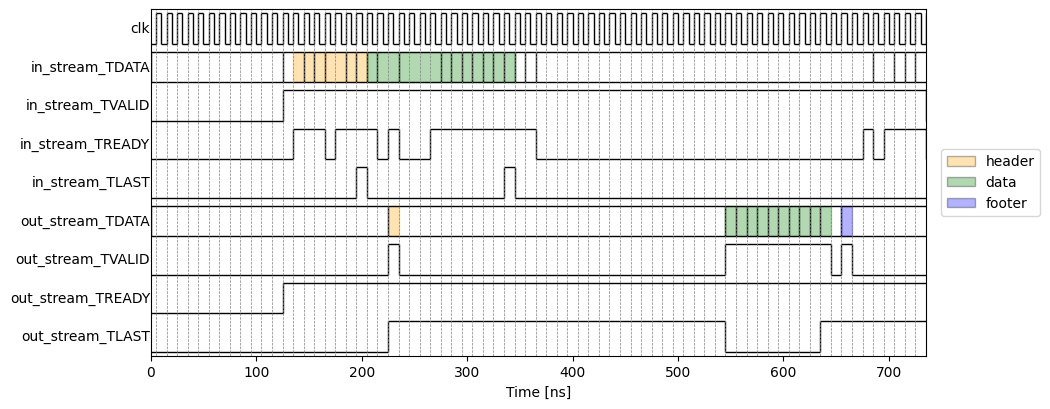

In [30]:
from matplotlib.patches import Patch

# Create the timing diagram
td = TimingDiagram()
td.add_signals(sig_list)
trange = None
ax = td.plot_signals(add_clk_grid=True, trange=trange, 
                text_scale_factor=1e4, text_mode='never')
_ = ax.set_xlabel('Time [ns]')

def color_burst(sig_name, burst, color, clk_period):
    t0 = burst['tstart']
    t1 = t0 + len(burst['beat_type']) * clk_period
    td.add_patch(sig_name=sig_name, time=[t0, t1], color=color, alpha=0.3)

hdr_color = 'orange'
data_color = 'green'
footer_color = 'blue'
color_burst(sig_name='in_stream_TDATA', burst=bursts_in[0], 
            color=hdr_color, clk_period=clk_period)
color_burst(sig_name='in_stream_TDATA', burst=bursts_in[1], 
            color=data_color, clk_period=clk_period)

color_burst(sig_name='out_stream_TDATA', burst=bursts_out[0], 
            color=hdr_color, clk_period=clk_period)
color_burst(sig_name='out_stream_TDATA', burst=bursts_out[1], 
            color=data_color, clk_period=clk_period)
color_burst(sig_name='out_stream_TDATA', burst=bursts_out[2], 
            color=footer_color, clk_period=clk_period)

legend_elements = [
    Patch(facecolor='orange', edgecolor='black', alpha=0.3, label='header'),
    Patch(facecolor='green', edgecolor='black', alpha=0.3, label='data'),
    Patch(facecolor='blue', edgecolor='black', alpha=0.3, label='footer'),
]
ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)

